## **Results from this Notebook**

| Feature   | Std   | Observation                | Insight                                        |
| --------- | ----- | -------------------------- | ---------------------------------------------- |
| Magnitude | 0.217 | stable                     |                                                |
| LogMel    | 0.212 | stable                     |                                                |
| MR256     | 0.228 | highest magnitude variance | captures transient detail                      |
| MR512     | 0.222 | good                       |                                                |
| MR1024    | 0.216 | similar to base            | mostly captures long harmonic structure        |
| IF        | 1.156 | very informative           | IF reacts strongly to environmental corruption |
| MODGD     | 0.918 | informative                |                                                |
| Phase Sin | 0.704 | healthy                    |                                                |
| Phase Cos | 0.710 | healthy                    |                                                |


In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import json
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

from src.utils.config_loader import load_yaml
from src.utils.path_manager import PathManager
from src.utils.metadata_manager import MetadataManager

from src.preprocessing.feature_dataset_builder import (
    FeatureDatasetBuilder
)

In [3]:
# --------------------------------------------------
# Load Configs
# --------------------------------------------------

data_cfg = load_yaml(
    PROJECT_ROOT
    / "configs"
    / "data_config.yaml"
)

feature_cfg = load_yaml(
    PROJECT_ROOT
    / "configs"
    / "feature_config.yaml"
)

feature_cfg

{'feature_extraction': {'sample_rate': 16000,
  'save_dtype': 'float32',
  'eps': '1e-8',
  'stft': {'n_fft': 1024,
   'win_length': 1024,
   'hop_length': 64,
   'window': 'hann'},
  'mel': {'n_mels': 80, 'fmin': 20, 'fmax': 8000},
  'multiresolution': {'fft_sizes': [256, 512, 1024],
   'hop_lengths': [32, 64, 128],
   'win_lengths': [256, 512, 1024]},
  'modgd': {'alpha': 0.4, 'gamma': 0.9}}}

In [4]:
# --------------------------------------------------
# Paths
# --------------------------------------------------

pm = PathManager(
    project_root=PROJECT_ROOT,
    config=data_cfg
)

FRAGMENT_DIR = pm.get_path(
    data_cfg["dataset"]["fragment_dir"]
)

FEATURE_DIR = pm.get_path(
    data_cfg["dataset"]["feature_dir"]
)

METADATA_DIR = pm.get_path(
    data_cfg["dataset"]["metadata_dir"]
)

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(FRAGMENT_DIR)
print(FEATURE_DIR)

d:\IITG\Projects\audio_factor_disentanglement_v2\data\fragments
d:\IITG\Projects\audio_factor_disentanglement_v2\data\features


In [5]:
# --------------------------------------------------
# Load Fragment Inventory
# --------------------------------------------------

fragment_inventory = MetadataManager.load_csv(

    METADATA_DIR
    / "fragment_inventory.csv"
)

print(
    f"Fragments : {len(fragment_inventory)}"
)

fragment_inventory.head()

Fragments : 311


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,end_time,duration,true_length,padded_length,padding_ratio,raw_file,tensor_file,total_fragments,relative_position
0,s1,clean,train,s1_clean_01.wav,0,0,0,10752,13056,0.672,0.816,0.144,2304,6336,0.636364,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.0
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,1.088,0.272,4352,6336,0.313131,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.2
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,1.368,0.216,3456,6336,0.454545,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.4
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,1.472,0.104,1664,6336,0.737374,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.6
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,1.568,0.096,1536,6336,0.757576,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.8


In [6]:
# --------------------------------------------------
# Builder
# --------------------------------------------------

builder = FeatureDatasetBuilder(
    feature_cfg
)

In [7]:
# --------------------------------------------------
# Generate Features
# --------------------------------------------------

feature_records = []

for _, row in tqdm(

    fragment_inventory.iterrows(),

    total=len(fragment_inventory)
):

    fragment_path = Path(
        row["raw_file"]
    )

    speaker = row["speaker"]

    source_file = Path(
        row["source_file"]
    ).stem

    fragment_id = int(
        row["fragment_id"]
    )

    output_dir = (

        FEATURE_DIR

        / speaker

        / source_file

        / f"fragment_{fragment_id:03d}"
    )

    metadata = builder.process_fragment(

        fragment_path=
            fragment_path,

        output_dir=
            output_dir,

        metadata=
            row.to_dict()
    )

    feature_records.append(
        metadata
    )

  0%|          | 0/311 [00:00<?, ?it/s]c:\Users\Dell\.conda\envs\betavae\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 311/311 [00:20<00:00, 15.46it/s]


In [8]:
# --------------------------------------------------
# Save Inventory
# --------------------------------------------------

feature_inventory = pd.DataFrame(
    feature_records
)

inventory_path = (

    METADATA_DIR
    / "feature_inventory_v2.csv"
)

MetadataManager.save_csv(

    feature_inventory,

    inventory_path
)

print(inventory_path)

d:\IITG\Projects\audio_factor_disentanglement_v2\data\metadata\feature_inventory_v2.csv


In [9]:
feature_inventory.head()

,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,...,modgd_shape,logmel_shape,mr_mag_256_shape,mr_phase_256_shape,mr_mag_512_shape,mr_phase_512_shape,mr_mag_1024_shape,mr_phase_1024_shape,available_features,sample_rate
0,s1,clean,train,s1_clean_01.wav,0,0,0,10752,13056,0.672,...,"[513, 37]","[80, 37]","[129, 73]","[129, 73]","[257, 37]","[257, 37]","[513, 19]","[513, 19]","[if, logmel, magnitude, modgd, mr_mag_1024, mr...",16000
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,...,"[513, 69]","[80, 69]","[129, 137]","[129, 137]","[257, 69]","[257, 69]","[513, 35]","[513, 35]","[if, logmel, magnitude, modgd, mr_mag_1024, mr...",16000
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,...,"[513, 55]","[80, 55]","[129, 109]","[129, 109]","[257, 55]","[257, 55]","[513, 28]","[513, 28]","[if, logmel, magnitude, modgd, mr_mag_1024, mr...",16000
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,...,"[513, 27]","[80, 27]","[129, 53]","[129, 53]","[257, 27]","[257, 27]","[513, 14]","[513, 14]","[if, logmel, magnitude, modgd, mr_mag_1024, mr...",16000
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,...,"[513, 25]","[80, 25]","[129, 49]","[129, 49]","[257, 25]","[257, 25]","[513, 13]","[513, 13]","[if, logmel, magnitude, modgd, mr_mag_1024, mr...",16000


In [10]:
# --------------------------------------------------
# Available Features
# --------------------------------------------------

example = feature_inventory.iloc[0]

example["available_features"]

['if',
 'logmel',
 'magnitude',
 'modgd',
 'mr_mag_1024',
 'mr_mag_256',
 'mr_mag_512',
 'mr_phase_1024',
 'mr_phase_256',
 'mr_phase_512',
 'phase',
 'phase_cos',
 'phase_sin']

In [11]:
# --------------------------------------------------
# Shape Metadata
# --------------------------------------------------

shape_cols = [

    c

    for c in feature_inventory.columns

    if c.endswith("_shape")
]

shape_cols

['magnitude_shape',
 'phase_shape',
 'phase_sin_shape',
 'phase_cos_shape',
 'if_shape',
 'modgd_shape',
 'logmel_shape',
 'mr_mag_256_shape',
 'mr_phase_256_shape',
 'mr_mag_512_shape',
 'mr_phase_512_shape',
 'mr_mag_1024_shape',
 'mr_phase_1024_shape']

In [12]:
feature_inventory[
    shape_cols
].head()

,magnitude_shape,phase_shape,phase_sin_shape,phase_cos_shape,if_shape,modgd_shape,logmel_shape,mr_mag_256_shape,mr_phase_256_shape,mr_mag_512_shape,mr_phase_512_shape,mr_mag_1024_shape,mr_phase_1024_shape
0,"[513, 37]","[513, 37]","[513, 37]","[513, 37]","[513, 37]","[513, 37]","[80, 37]","[129, 73]","[129, 73]","[257, 37]","[257, 37]","[513, 19]","[513, 19]"
1,"[513, 69]","[513, 69]","[513, 69]","[513, 69]","[513, 69]","[513, 69]","[80, 69]","[129, 137]","[129, 137]","[257, 69]","[257, 69]","[513, 35]","[513, 35]"
2,"[513, 55]","[513, 55]","[513, 55]","[513, 55]","[513, 55]","[513, 55]","[80, 55]","[129, 109]","[129, 109]","[257, 55]","[257, 55]","[513, 28]","[513, 28]"
3,"[513, 27]","[513, 27]","[513, 27]","[513, 27]","[513, 27]","[513, 27]","[80, 27]","[129, 53]","[129, 53]","[257, 27]","[257, 27]","[513, 14]","[513, 14]"
4,"[513, 25]","[513, 25]","[513, 25]","[513, 25]","[513, 25]","[513, 25]","[80, 25]","[129, 49]","[129, 49]","[257, 25]","[257, 25]","[513, 13]","[513, 13]"


In [16]:
# --------------------------------------------------
# Example Fragment
# --------------------------------------------------

example = feature_inventory.iloc[18]

speaker = example["speaker"]

source_file = Path(
    example["source_file"]
).stem

fragment_id = int(
    example["fragment_id"]
)

feature_folder = (

    FEATURE_DIR

    / speaker

    / source_file

    / f"fragment_{fragment_id:03d}"
)

feature_folder

WindowsPath('d:/IITG/Projects/audio_factor_disentanglement_v2/data/features/s1/s1_clean_03/fragment_005')

In [17]:
# --------------------------------------------------
# Inspect Files
# --------------------------------------------------

sorted(
    [
        x.name
        for x in feature_folder.glob("*")
    ]
)

['feature_metadata.json',
 'if.npy',
 'logmel.npy',
 'magnitude.npy',
 'modgd.npy',
 'mr_mag_1024.npy',
 'mr_mag_256.npy',
 'mr_mag_512.npy',
 'mr_phase_1024.npy',
 'mr_phase_256.npy',
 'mr_phase_512.npy',
 'phase.npy',
 'phase_cos.npy',
 'phase_sin.npy']

In [18]:
# --------------------------------------------------
# Load Features
# --------------------------------------------------

magnitude = np.load(
    feature_folder / "magnitude.npy"
)

phase = np.load(
    feature_folder / "phase.npy"
)

phase_sin = np.load(
    feature_folder / "phase_sin.npy"
)

phase_cos = np.load(
    feature_folder / "phase_cos.npy"
)

if_feature = np.load(
    feature_folder / "if.npy"
)

modgd = np.load(
    feature_folder / "modgd.npy"
)

logmel = np.load(
    feature_folder / "logmel.npy"
)

mr_mag_256 = np.load(
    feature_folder / "mr_mag_256.npy"
)

mr_mag_512 = np.load(
    feature_folder / "mr_mag_512.npy"
)

mr_mag_1024 = np.load(
    feature_folder / "mr_mag_1024.npy"
)

In [19]:
print("Magnitude :", magnitude.shape)
print("Phase :", phase.shape)
print("PhaseSin :", phase_sin.shape)
print("PhaseCos :", phase_cos.shape)

print("IF :", if_feature.shape)
print("MODGD :", modgd.shape)

print("LogMel :", logmel.shape)

print("MR256 :", mr_mag_256.shape)
print("MR512 :", mr_mag_512.shape)
print("MR1024 :", mr_mag_1024.shape)

Magnitude : (513, 79)
Phase : (513, 79)
PhaseSin : (513, 79)
PhaseCos : (513, 79)
IF : (513, 79)
MODGD : (513, 79)
LogMel : (80, 79)
MR256 : (129, 157)
MR512 : (257, 79)
MR1024 : (513, 40)


In [20]:
import matplotlib.pyplot as plt

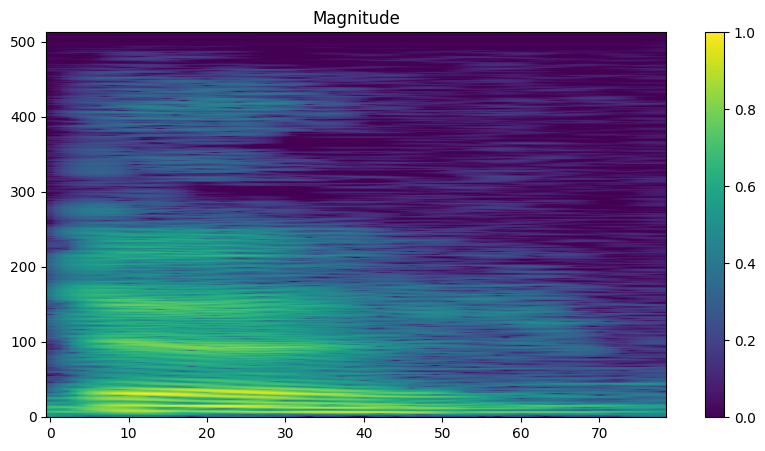

In [21]:
plt.figure(figsize=(10,5))

plt.imshow(

    magnitude,

    aspect="auto",

    origin="lower"
)

plt.title(
    "Magnitude"
)

plt.colorbar()

plt.show()

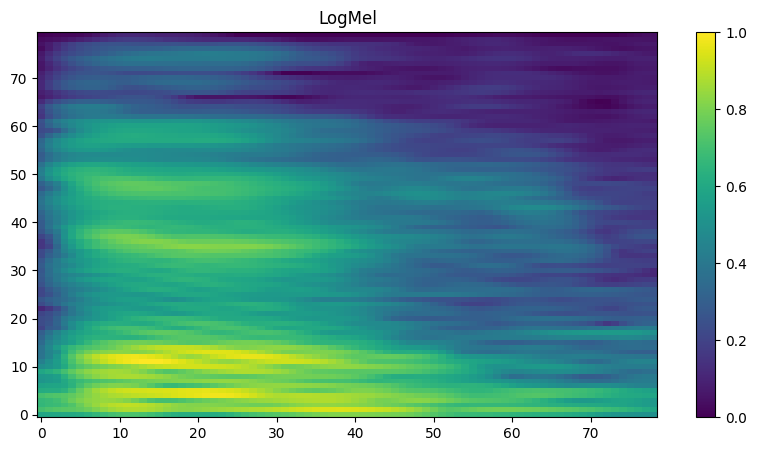

In [22]:
plt.figure(figsize=(10,5))

plt.imshow(

    logmel,

    aspect="auto",

    origin="lower"
)

plt.title(
    "LogMel"
)

plt.colorbar()

plt.show()

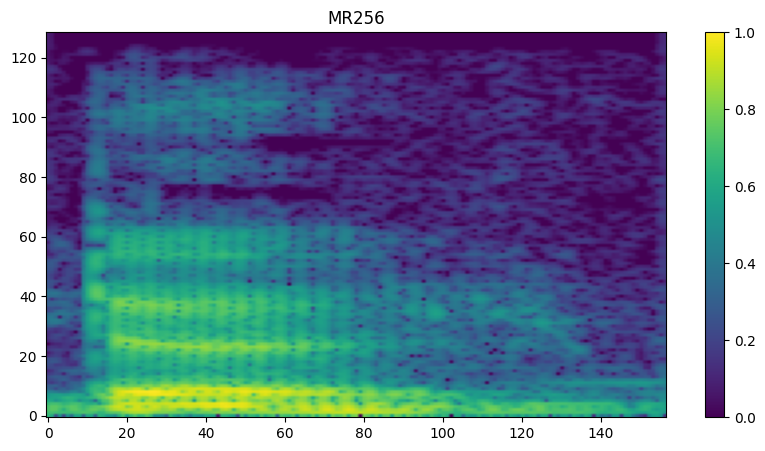

In [23]:
plt.figure(figsize=(10,5))

plt.imshow(

    mr_mag_256,

    aspect="auto",

    origin="lower"
)

plt.title(
    "MR256"
)

plt.colorbar()

plt.show()

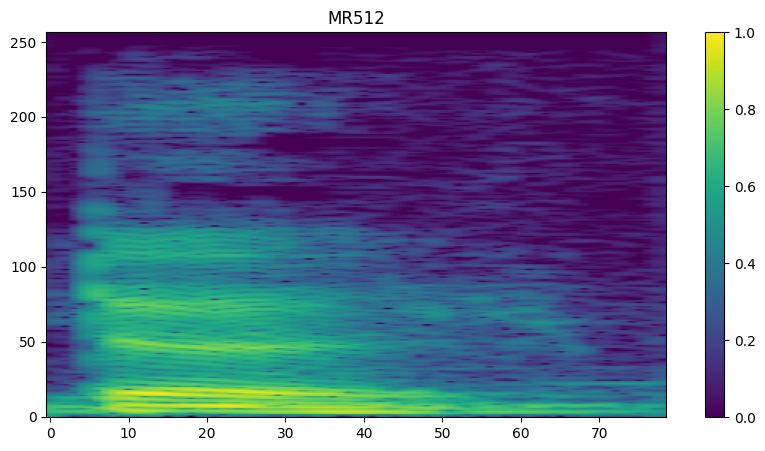

In [24]:
plt.figure(figsize=(10,5))

plt.imshow(

    mr_mag_512,

    aspect="auto",

    origin="lower"
)

plt.title(
    "MR512"
)

plt.colorbar()

plt.show()

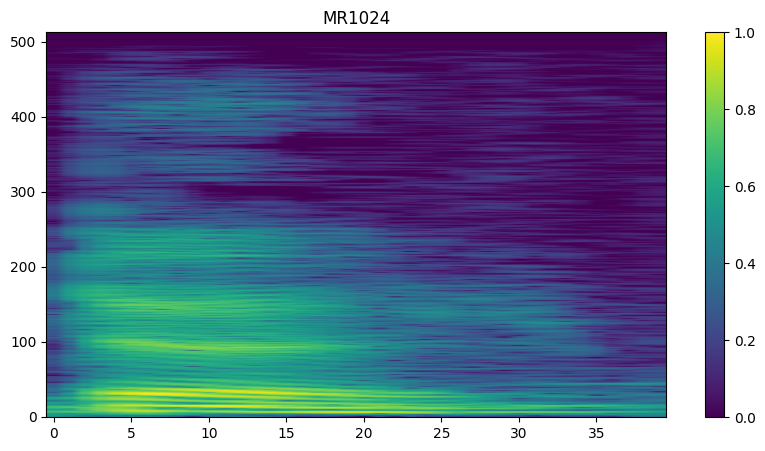

In [25]:
plt.figure(figsize=(10,5))

plt.imshow(

    mr_mag_1024,

    aspect="auto",

    origin="lower"
)

plt.title(
    "MR1024"
)

plt.colorbar()

plt.show()

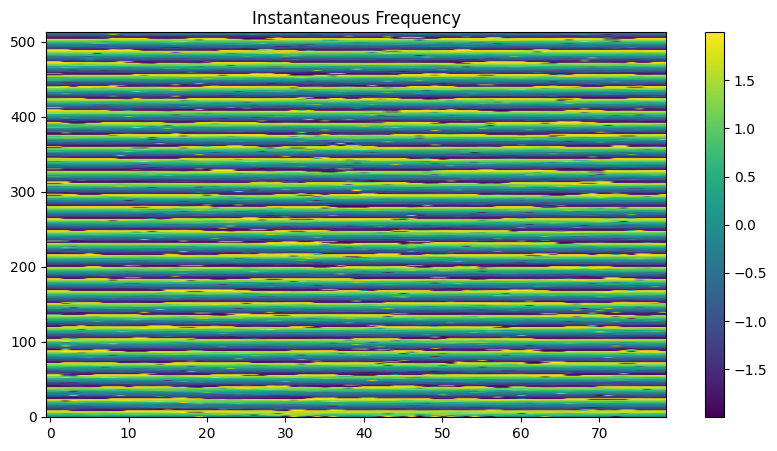

In [26]:
plt.figure(figsize=(10,5))

plt.imshow(

    if_feature,

    aspect="auto",

    origin="lower"
)

plt.title(
    "Instantaneous Frequency"
)

plt.colorbar()

plt.show()

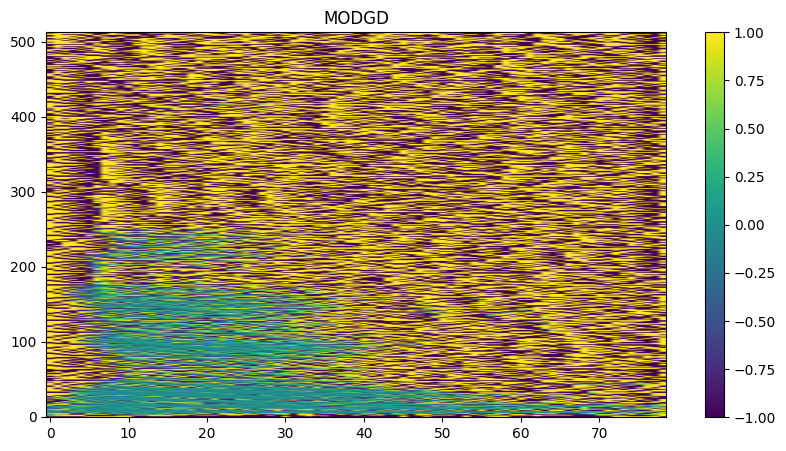

In [27]:
plt.figure(figsize=(10,5))

plt.imshow(

    modgd,

    aspect="auto",

    origin="lower"
)

plt.title(
    "MODGD"
)

plt.colorbar()

plt.show()

In [28]:
# --------------------------------------------------
# Feature Statistics Builder
# --------------------------------------------------

from src.preprocessing.feature_statistics import (
    FeatureStatisticsBuilder
)

stats_builder = (
    FeatureStatisticsBuilder()
)

In [29]:
# --------------------------------------------------
# Compute Statistics
# --------------------------------------------------

feature_stats = (

    stats_builder.compute_stats(

        feature_inventory=
            feature_inventory,

        feature_dir=
            FEATURE_DIR
    )
)


Processing magnitude


100%|██████████| 311/311 [00:03<00:00, 94.20it/s] 



Processing logmel


100%|██████████| 311/311 [00:03<00:00, 86.25it/s]



Processing if


...

100%|██████████| 311/311 [00:03<00:00, 79.44it/s] 



Processing phase_sin


100%|██████████| 311/311 [00:04<00:00, 75.69it/s]



Processing phase_cos


100%|██████████| 311/311 [00:04<00:00, 75.59it/s]


In [30]:
feature_stats.keys()

dict_keys(['magnitude', 'logmel', 'if', 'modgd', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'phase_sin', 'phase_cos'])

In [31]:
import pandas as pd

pd.DataFrame(
    feature_stats
).T

,mean,std,min,max,p01,p99
magnitude,0.345183,0.216861,0.000000,1.000000,0.000000,0.872260
logmel,0.517850,0.212406,0.000000,1.000000,0.061353,0.951890
if,0.000436,1.155854,-2.051724,2.043743,-1.966803,1.966846
modgd,0.002080,0.917926,-1.000000,1.000000,-1.000000,1.000000
mr_mag_256,0.391758,0.227544,0.000000,1.000000,0.000000,0.922143
mr_mag_512,0.365740,0.221720,0.000000,1.000000,0.000000,0.894778
mr_mag_1024,0.345489,0.216437,0.000000,1.000000,0.000000,0.871876
phase_sin,0.000005,0.704029,-1.000000,1.000000,-0.999510,0.999506
phase_cos,-0.000172,0.710172,-1.000000,1.000000,-0.999714,0.999684


In [32]:
# --------------------------------------------------
# Save
# --------------------------------------------------

stats_path = (

    METADATA_DIR
    / "feature_stats.json"
)

stats_builder.save(

    feature_stats,

    stats_path
)

print(
    stats_path
)

d:\IITG\Projects\audio_factor_disentanglement_v2\data\metadata\feature_stats.json


In [33]:
import json

with open(
    stats_path,
    "r"
) as f:

    stats = json.load(f)

stats

{'magnitude': {'mean': 0.3451825678348541,
  'std': 0.2168610394001007,
  'min': 0.0,
  'max': 1.0,
  'p01': 0.0,
  'p99': 0.8722599744796753},
 'logmel': {'mean': 0.5178497433662415,
  'std': 0.21240566670894623,
  'min': 0.0,
  'max': 1.0,
  'p01': 0.06135280430316925,
  'p99': 0.951890230178833},
 'if': {'mean': 0.0004355084674898535,
  'std': 1.155853509902954,
  'min': -2.0517239570617676,
  'max': 2.0437426567077637,
  'p01': -1.966802716255188,
  'p99': 1.9668458700180054},
 'modgd': {'mean': 0.0020796984899789095,
  'std': 0.917926013469696,
  'min': -1.0,
  'max': 1.0,
  'p01': -1.0,
  'p99': 1.0},
 'mr_mag_256': {'mean': 0.3917578160762787,
  'std': 0.2275436371564865,
  'min': 0.0,
  'max': 1.0,
  'p01': 0.0,
  'p99': 0.9221431016921997},
 'mr_mag_512': {'mean': 0.3657395839691162,
  'std': 0.22171971201896667,
  'min': 0.0,
  'max': 1.0,
  'p01': 0.0,
  'p99': 0.894778311252594},
 'mr_mag_1024': {'mean': 0.3454892635345459,
  'std': 0.21643735468387604,
  'min': 0.0,
  'max

In [34]:
feature_stats["if"]
feature_stats["modgd"]
feature_stats["magnitude"]
feature_stats["logmel"]

{'mean': 0.5178497433662415,
 'std': 0.21240566670894623,
 'min': 0.0,
 'max': 1.0,
 'p01': 0.06135280430316925,
 'p99': 0.951890230178833}